#Redes Neuronales Convolucionales: Diversas arquitecturas


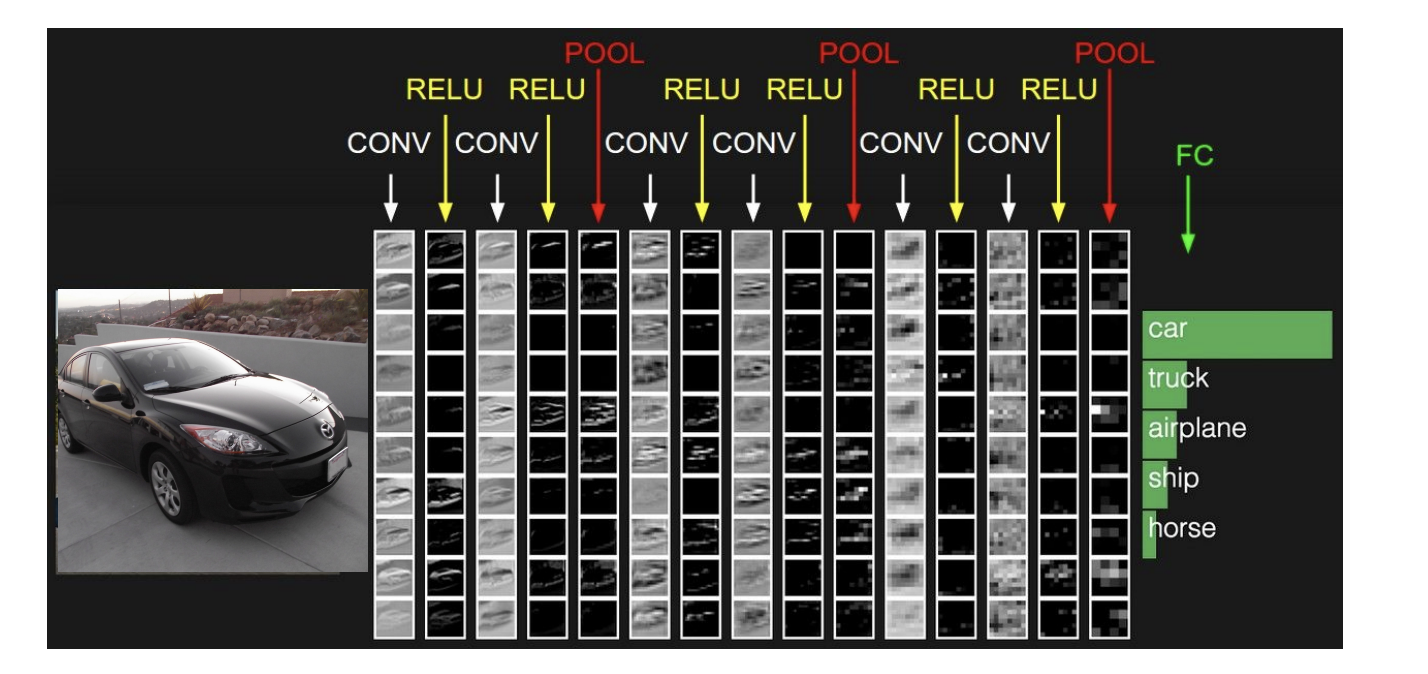

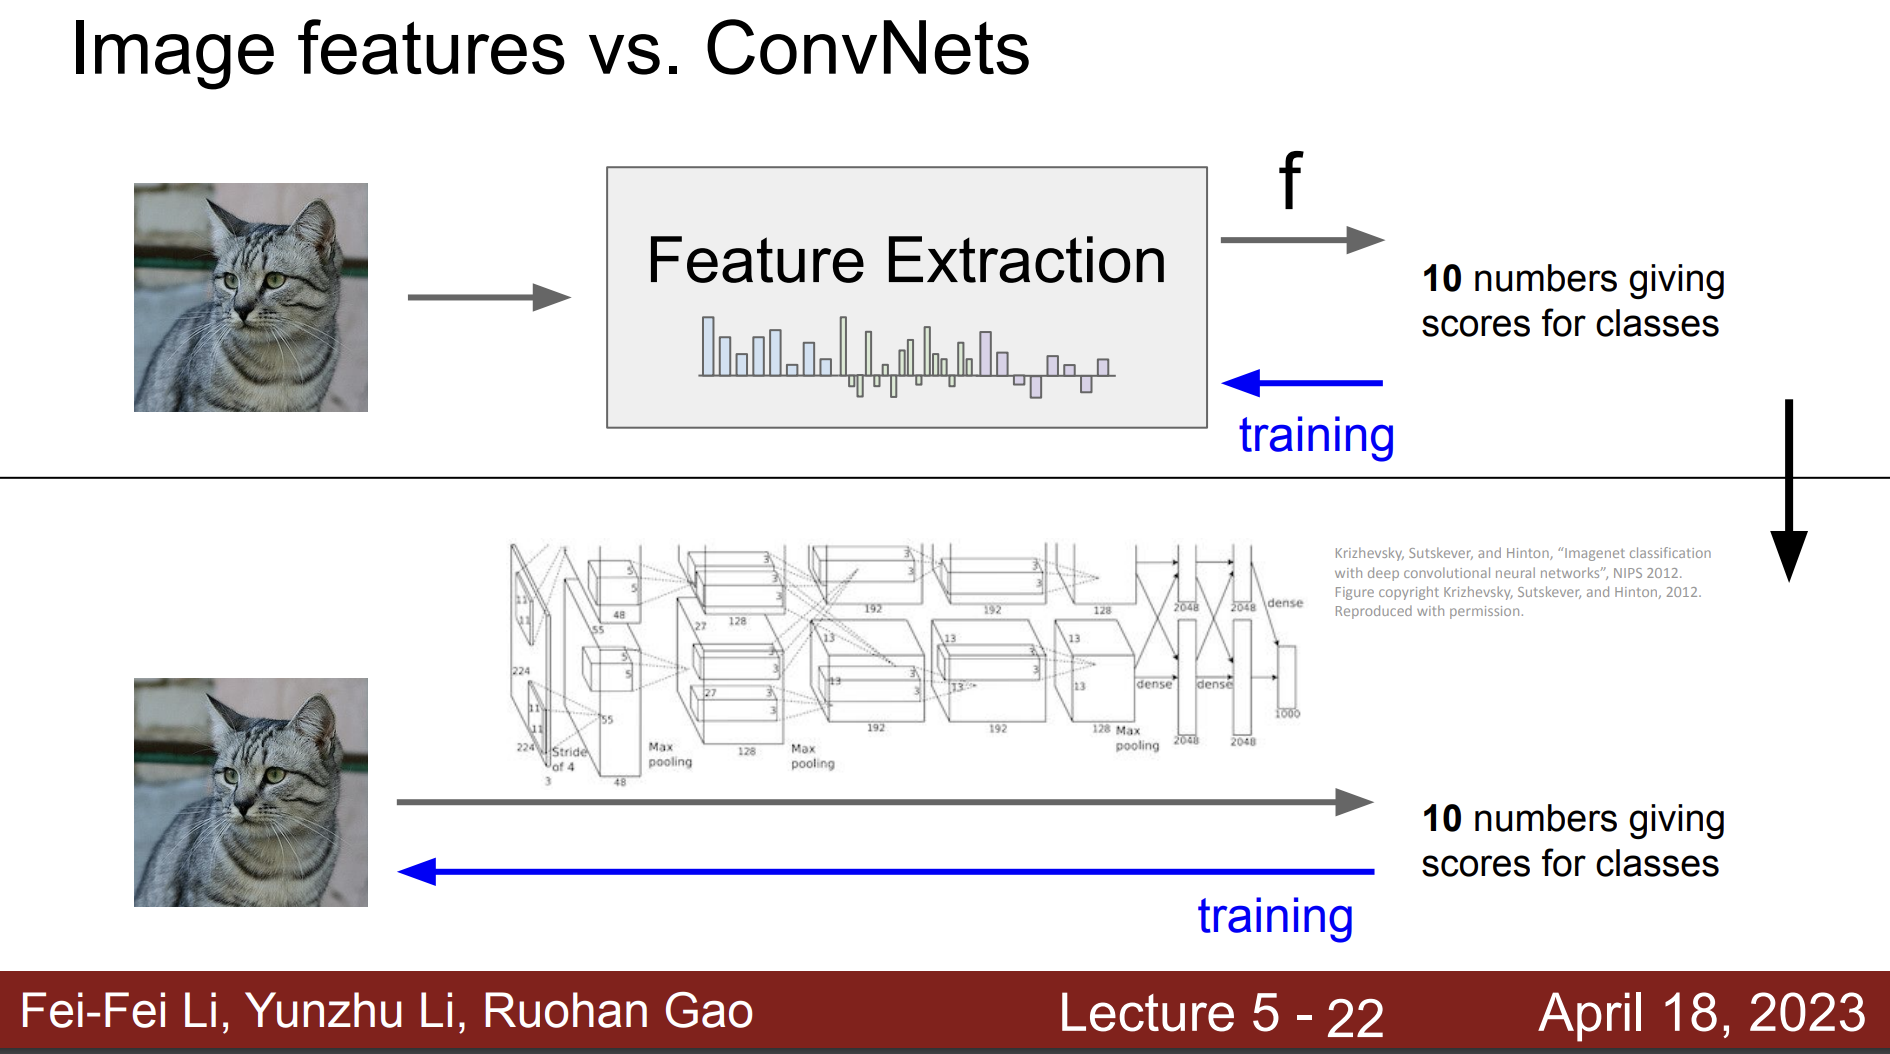

## Repaso

Recordemos las capas que conforman este tipo de red:

1- Convolucionales

2- Pooling

3- Densas

1- Capas convolucionales:

Ejemplo: https://cs231n.github.io/assets/conv-demo/index.html

En keras:

```
from keras.layers import Conv2D

# Ejemplo de una capa convolucional en Keras

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(image_height, image_width, channels)))
```

2- Pooling:

Puede ser max, min, average. Ejemplo con max pooling:

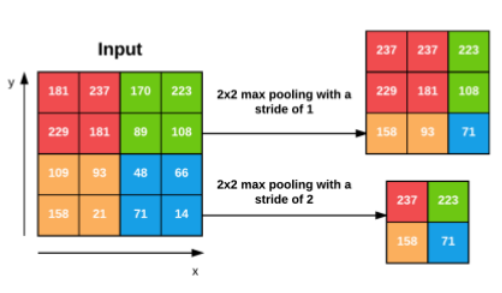

En keras:

```
from keras.layers import MaxPooling2D

# Ejemplo de una capa de Max Pooling en Keras
model.add(MaxPooling2D(pool_size=(2, 2)))
```

3- Capas densas:

Son el mismo tipo de capa que intervienen en el perceptrón multicapa.

En keras:

```
from keras.layers import Dense, Flatten

# Aplanar las características
model.add(Flatten())

# Agregar una capa completamente conectada
model.add(Dense(512, activation='relu'))
```

El **stride** \( S \) se refiere a la cantidad de píxeles por los que desplazamos el filtro sobre la imagen de entrada. Controla cómo el filtro convolucional se aplica a la matriz de entrada.

- Un **stride** de 1 mantiene la resolución espacial de la imagen.
- Un **stride** mayor que 1 reduce la resolución espacial, útil para disminuir la dimensionalidad y aumentar el campo receptivo.

La fórmula para calcular las dimensiones de salida $( W')$ y $( H')$ con un tamaño de entrada $( W \times H )$, un tamaño de filtro \( F \), y un stride \( S \) es:

$$
W' = \left\lfloor \frac{W - F}{S} + 1 \right\rfloor
$$
$$
H' = \left\lfloor \frac{H - F}{S} + 1 \right\rfloor
$$

El **padding** \( P \) se refiere a la adición de píxeles alrededor de la imagen de entrada, que permite controlar la reducción de tamaño y preservar la información de los bordes.

- **Valid Padding** significa que no se añade padding, y la salida se reduce en función del tamaño de filtro y el stride.
- **Same Padding** añade suficiente padding para mantener el tamaño de salida igual al tamaño de entrada cuando \( S = 1 \).

Incluyendo el padding, las dimensiones de salida se ajustan a:

$$
W' = \left\lfloor \frac{W - F + 2P}{S} + 1 \right\rfloor
$$
$$
H' = \left\lfloor \frac{H - F + 2P}{S} + 1 \right\rfloor
$$


### Capas convolucionales 1x1

Las capas convolucionales de 1x1, a veces conocidas como convoluciones de "punto" debido a que operan en un solo punto de las características de entrada, son un componente útil en las arquitecturas de redes neuronales convolucionales por varias razones:

**Reducción de Dimensionalidad**: Una convolución 1x1 con menos filtros que la profundidad de entrada puede reducir la profundidad de las características, es decir, el número de canales de salida. Esto es útil para disminuir el número de cálculos en las capas siguientes y para reducir la complejidad del modelo.

**Aumento de Dimensionalidad**: Inversamente, si se utilizan más filtros que la profundidad de entrada, una convolución 1x1 puede aumentar la profundidad de las características. Esto puede ser útil para preparar las características para una operación subsiguiente que requiere una mayor profundidad.

**Preservación de la Dimensión Espacial**: Las convoluciones 1x1 no afectan las dimensiones espaciales de la entrada (altura y anchura), lo que las hace útiles para ajustar la profundidad sin cambiar el tamaño espacial.

**Conexiones Densas en el Espacio de Canales**: Permiten que cada salida de la capa anterior sea una combinación lineal de todas las entradas (canal por canal), lo que posibilita que la red combine características entre los canales. Esto aumenta la capacidad del modelo para aprender interacciones complejas entre canales.

**Implementación de MLP en el Espacio de Características**: Cuando se apilan varias capas convolucionales 1x1 con funciones de activación no lineales entre ellas, efectivamente se está realizando un perceptrón multicapa en cada ubicación de las características espaciales, lo que permite aprender representaciones más complejas.

**Eficiencia Computacional**: Las convoluciones 1x1 son computacionalmente más eficientes en comparación con las convoluciones más grandes, especialmente cuando se combinan con reducción de dimensionalidad.

**Uso en Arquitecturas Avanzadas**: Se utilizan en arquitecturas de CNN modernas como Inception (para reducir dimensiones antes de convoluciones más costosas) y ResNet (para aprender residuos).


En la práctica, las capas de convolución 1x1 son una herramienta versátil para la ingeniería de características dentro de las redes neuronales convolucionales y son un componente estándar en muchos modelos de vanguardia.

## Regularización

Conforme se hace el entrenamiento, las CNNs pueden presentar diversos problemas relacionados con los datos, capacidad de generalización y complejidad del modelo. Las técnicas de regulación colaboran para aliviar sus efectos, en función de tener buenos modelos.

Beneficios de aplicar regularización en nuestros modelos:

* Mejora la Generalización: Incluso en ausencia de overfitting severo, la regularización puede ayudar a mejorar la capacidad de generalización del modelo. Al limitar la complejidad del modelo, la regularización asegura que no se ajuste demasiado a los detalles del conjunto de entrenamiento que son irrelevantes para la tarea.

* Gestión de Ruido en los Datos: En muchos casos, los datos de entrenamiento pueden contener ruido. La regularización ayuda a que el modelo sea menos sensible a este ruido, permitiendo que aprenda las características subyacentes en lugar de memorizar el ruido.

* Estabilidad Numérica: Algunas técnicas de regularización, como la normalización por lotes (batch normalization), pueden mejorar la estabilidad numérica del proceso de entrenamiento al normalizar las entradas de las capas.
Rápida Convergencia: La regularización puede ayudar a que la optimización converja más rápido al evitar grandes fluctuaciones en los pesos durante el entrenamiento.

* Alivia el Problema del Desvanecimiento o Explosión de Gradientes: Técnicas como la normalización por lotes no solo regularizan sino que también pueden aliviar el problema del desvanecimiento o explosión de gradientes en redes muy profundas.
Promueve la Dispersión de Características: Algunas formas de regularización, como la regularización L1, pueden promover la dispersión de las características al penalizar los pesos de forma tal que el modelo se ve forzado a usar solo las características más informativas.

* Arquitecturas Más Profundas: En el caso de las CNNs muy profundas, la regularización es crucial para poder entrenar efectivamente, ya que estas redes tienen una mayor tendencia al overfitting debido a su complejidad y número de parámetros.

* Requisitos de Infraestructura: En algunos casos, la regularización permite entrenar modelos más grandes en hardware limitado, ya que modelos bien regularizados pueden ser más fáciles de entrenar y menos propensos a requerir tanto ajuste fino.



### Técnicas de Regularización en Keras

#### Dropout
Dropout es una técnica de regularización que aleatoriamente "apaga" un número de salidas de neuronas durante el entrenamiento. La fórmula para Dropout en una neurona es:

`y = x * (1 - dropout_rate)`

$$
y_i =
\begin{cases}
0 & \text{con probabilidad } p \\
\frac{x_i}{1 - p} & \text{con probabilidad } 1 - p
\end{cases}
$$

Donde `x` es la entrada a la neurona, `p` es la probabilidad de que una neurona sea "descartada" y no se utilice durante la iteración actual, e `y` es la salida.

En Keras, se implementa como una capa:

```python
from keras.layers import Dropout

# Añade Dropout a tu modelo de Keras
model.add(Dropout(0.5)) # `0.5` es el dropout_rate
```

#### Regularización L1/L2

La regularización L1 y L2 son técnicas que penalizan los coeficientes de las neuronas durante el entrenamiento para evitar el overfitting.

La regularización L1 es la suma del valor absoluto de los pesos:


$$ L1(\theta) = \lambda \sum_{i=1}^{n} |\theta_i| $$

La regularización L2 es la suma de los cuadrados de los pesos:

$$ L2(\theta) = \lambda \sum_{i=1}^{n} \theta_i^2 $$


En Keras, puedes añadir regularización L1 o L2 a una capa:

```
from keras.regularizers import l1, l2

# Regularización L1
model.add(Dense(64, activation='relu', kernel_regularizer=l1(0.01)))

# Regularización L2
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))

```

**Regularización en Capas Convolucionales**

La regularización en las capas convolucionales se aplica generalmente a los pesos de los filtros convolucionales para penalizar los pesos grandes y así prevenir el sobreajuste (overfitting). Esto se puede hacer utilizando regularizadores L1, L2 o una combinación de ambos (L1_L2). En Keras, puedes añadir regularización directamente en la capa convolucional usando el argumento kernel_regularizer.

```
from keras.layers import Conv2D
from keras.regularizers import l1, l2, l1_l2

# Añadir una capa convolucional con regularización L2
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3),
                 kernel_regularizer=l2(0.001)))
```

Las capas de pooling generalmente no tienen parámetros entrenables (no tienen pesos), por lo que no se aplica regularización directamente a ellas. Su propósito es más bien reducir la dimensionalidad espacial de las representaciones intermedias (features maps) y proporcionar invarianza a pequeñas traslaciones y distorsiones en la imagen.

**Dropout:** Aunque el Dropout se utiliza típicamente en las capas completamente conectadas (dense layers), también puede aplicarse después de las capas convolucionales para regularizar y prevenir el overfitting.

#### Normalización por Lotes (Batch Normalization)

La normalización por lotes normaliza las salidas de la capa anterior en subconjuntos del dataset (mini-lotes), lo que mejora la estabilidad del entrenamiento.

La fórmula es:

$$ \hat{x}^{(k)} = \frac{x^{(k)} - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}} $$

$$ y^{(k)} = \gamma \hat{x}^{(k)} + \beta = \text{BN}_{\gamma, \beta}(x^{(k)}) $$


Donde x es la entrada, mean y variance son calculados sobre el mini-lote, gamma y beta son parámetros aprendidos, y epsilon es un pequeño número para evitar la división por cero.

En Keras, se implementa como:
```
from keras.layers import BatchNormalization

# Añadir normalización por lotes
model.add(BatchNormalization())
```

También se emplea después de las capas convolucionales para normalizar las salidas y puede tener un efecto regularizador al limitar el espacio de los parámetros que el modelo puede utilizar.


#### Early Stopping

Es una forma de regularización utilizada para evitar el sobreajuste (overfitting) durante el entrenamiento de un modelo de aprendizaje automático. Se basa en detener el entrenamiento tan pronto como el rendimiento en el conjunto de validación comienza a empeorar, lo que suele ser una señal de que el modelo está empezando a memorizar los datos en lugar de aprender características generalizables.

En keras:

```
from keras.callbacks import EarlyStopping

# Configurar Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min', restore_best_weights=True)

# Añadir Early Stopping al entrenamiento del modelo
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, callbacks=[early_stopping])
```

#### Funcionamiento de la regularización

Ejemplo para L2:

La regularización L2, también conocida como "weight decay" en el contexto de las redes neuronales, añade un término de penalización que es proporcional al cuadrado de la magnitud de los coeficientes (los pesos en el modelo). Este término de penalización se añade a la función de pérdida del modelo. Matemáticamente, la función de pérdida regularizada L2 se define como:


$$
\text{Costo total} = \text{Costo de la pérdida} + \frac{\lambda}{2N} \sum_{i=1}^{n} w_i^2
$$

donde:

- $\text{Costo de la pérdida}$ es la pérdida calculada por la función de pérdida principal del modelo (por ejemplo, pérdida de entropía cruzada para clasificación).
- $\lambda$ es el parámetro de regularización que controla el grado de penalización de los grandes pesos y ayuda a prevenir el sobreajuste.
- $N$ es el número total de muestras en el conjunto de entrenamiento.
- $w_i$ representa los pesos asociados con las neuronas en el modelo.
- $\sum_{i=1}^{n} w_i^2$ es la suma de los cuadrados de todos los pesos del modelo, que constituye la parte de regularización L2 de la función de costo.


Durante el entrenamiento, el optimizador actualiza los pesos no solo en función del gradiente de la función de pérdida original, sino también teniendo en cuenta este término de penalización. Esto significa que los pesos no solo están influenciados por el error que el modelo hace en las predicciones, sino también por su magnitud.

Durante el entrenamiento, Keras se encargará automáticamente de añadir el término de regularización L2 al costo y actualizar los pesos de acuerdo con el gradiente total.

El efecto de la regularización L2 es que los pesos tienden a ser más pequeños (en términos de su valor absoluto), lo cual a menudo conduce a un modelo más simple que tiene menos riesgo de sobreajustarse a los datos de entrenamiento.

En Keras, al especificar un regularizador en la capa, se aplica a los pesos (también conocidos como el "kernel") de esa capa particular. Esto significa que durante el entrenamiento, el costo total incluirá un término adicional que penaliza los valores grandes de los pesos de estas capas, intentando mantenerlos pequeños.

Es importante notar que no es obligatorio aplicar la misma cantidad de regularización a todas las capas. Puedes elegir aplicar regularización más fuerte o más débil a capas específicas, o incluso omitir la regularización en algunas capas, según lo que mejor funcione para tu modelo y tus datos.

La regularización también se puede aplicar a los sesgos de una capa si se considera necesario, pero esto es menos común ya que los pesos suelen ser el foco principal para evitar el sobreajuste.

#### Cuando aplicar regularización

La decisión de aplicar regularización a algunas capas y no a otras en redes neuronales convolucionales (CNNs) depende de varios factores y puede ser guiada por la comprensión de la arquitectura del modelo, el conjunto de datos y los resultados experimentales. No hay una regla estricta, pero veamos algunas pautas generales:

**Capas Convolucionales**

Inicio de la Red:

Las capas convolucionales iniciales aprenden características básicas como bordes y texturas. Estas características simples son más generales y menos propensas al sobreajuste, por lo que la regularización en estas capas puede ser menos necesaria.

Capas Profundas:

Las capas convolucionales más profundas aprenden características de alto nivel más complejas y específicas de los datos. Estas pueden ser más propensas al sobreajuste, especialmente si el conjunto de datos es pequeño o si las capas tienen muchos filtros. Por lo tanto, aplicar regularización L2 en estas capas puede ser más beneficioso.

**Capas Densas**

Las capas densas, especialmente las que tienen un gran número de parámetros, son donde el sobreajuste es a menudo más preocupante. La regularización (L1, L2 o ambas) es comúnmente aplicada aquí.


**Batch Normalization**

Aunque no es una técnica de regularización per se, tiene efectos regularizadores. Si estás usando la normalización por lotes, es posible que necesites menos regularización, ya que esta técnica puede reducir el sobreajuste por sí misma.

**Dropout**

Es efectivo tanto en capas convolucionales como densas, pero se usa con más frecuencia en capas densas. Puede ser menos útil en capas convolucionales, especialmente justo después de capas de normalización por lotes.

#### Experimentación

#### Guías Experimentales

**Pruebas y Validación**

Comienza sin regularización o con una regularización leve. Si observas sobreajuste (alta precisión en el entrenamiento pero baja precisión en la validación), considera agregar o aumentar la regularización en las capas pertinentes.

**Validación Cruzada**

Realiza validación cruzada para determinar si la regularización mejora el rendimiento en los datos de validación y no solo en los datos de entrenamiento.

**Visualización**

Observa las activaciones y los pesos. Si las activaciones o los pesos parecen ruidosos o poco estructurados, puede ser una señal de que la regularización podría ser beneficiosa.
Gran Número de Filtros: Si tienes muchas características (filtros) en capas convolucionales, aplicar regularización puede evitar que aprendan ruido o patrones irrelevantes.


**Tamaño del Dataset**

Para datasets más grandes, la necesidad de regularización puede disminuir, mientras que para datasets más pequeños, la regularización se vuelve más crítica.

**Balance y Trade-offs**

Rendimiento vs. Generalización: Encuentra un equilibrio entre el rendimiento del modelo en los datos de entrenamiento y su capacidad de generalización en los datos de validación/prueba.
En última instancia, la aplicación de regularización es una decisión empírica y debe ser guiada por experimentación y validación. Es importante iterar sobre diferentes configuraciones y monitorear cómo cada cambio afecta al rendimiento del modelo.

### Ejercicio:

1- Construye un modelo CNN básico para el dataset UC Merced. Por ejemplo, con 6 capas convolucionales y de max pooling.

2- Entrena el modelo y observa si hay signos de overfitting.

3- Implementa técnicas de regularización como dropout y regularización L2. Cuál fue la que mejor resultó?

4- Emplea Early Stopping para evitar entrenar el modelo más de lo necesario.

5- Compara el rendimiento del modelo antes y después de aplicar las técnicas de regularización.

### Algunas arquitecturas reconocidas

Veamos algunas arquitecturas que implementan lo que fuimos viendo, entrenadas en grandes datasets.

* LeNet
* AlexNet
* VGG
* ResNet

#### LeNet

Paper: http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

Historia y Contexto:

LeNet es una de las primeras redes neuronales convolucionales, diseñada por Yann LeCun en 1998, principalmente para tareas de reconocimiento de dígitos y escritura a mano, como el dataset MNIST.

Arquitectura:
La arquitectura típica de LeNet consta de capas convolucionales seguidas de capas de subsampling (pooling), y termina con capas densas.

Detalles Técnicos:

Utiliza filtros de convolución pequeños.
Implementa subsampling mediante average pooling.
Utiliza la función de activación tanh o sigmoid.
Implementación en Keras:

```
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

lenet = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)),
    AveragePooling2D(),
    Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    AveragePooling2D(),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])
```

#### AlexNet

Paper: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

Historia y Contexto:

AlexNet ganó fama tras ganar la competencia ImageNet Large Scale Visual Recognition Challenge en 2012. Fue diseñada por Alex Krizhevsky y es conocida por ser significativamente más profunda y efectiva que LeNet.

Arquitectura:
AlexNet consta de cinco capas convolucionales, algunas seguidas por max-pooling, y tres capas densas al final. También introdujo el uso de ReLU como función de activación.

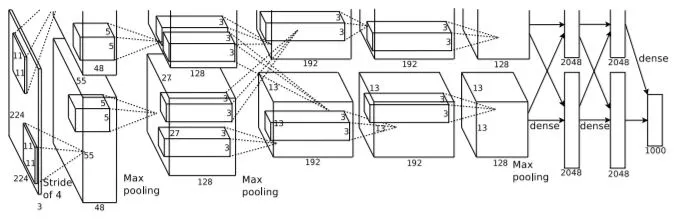

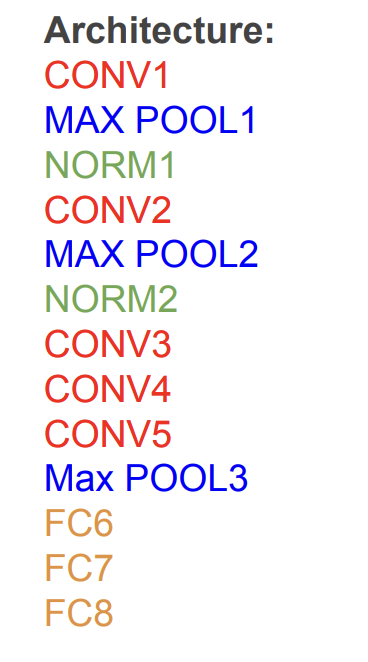

Detalles Técnicos:

Usa ReLU en lugar de tanh para acelerar la convergencia.
Implementa el dropout y la normalización de respuesta local para reducir el overfitting.
Utiliza data augmentation y entrenamiento estocástico de descenso de gradiente.
Implementación en Keras:

```
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Configuración del modelo
alexnet = Sequential()

# Primera capa convolucional
alexnet.add(Conv2D(96, kernel_size=(11, 11), strides=4, activation='relu', input_shape=(227, 227, 3)))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(3, 3), strides=2))

# Segunda capa convolucional
alexnet.add(Conv2D(256, kernel_size=(5, 5), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(3, 3), strides=2))

# Tercera, cuarta y quinta capas convolucionales
alexnet.add(Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'))
alexnet.add(Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'))
alexnet.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
alexnet.add(MaxPooling2D(pool_size=(3, 3), strides=2))

# Aplanamiento y capas densas
alexnet.add(Flatten())
alexnet.add(Dense(4096, activation='relu'))
alexnet.add(Dropout(0.5))
alexnet.add(Dense(4096, activation='relu'))
alexnet.add(Dropout(0.5))

# Capa de salida
alexnet.add(Dense(1000, activation='softmax'))  # Número de clases en ImageNet

# Compilación del modelo
alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
alexnet.summary()
```

Nota: este código no incluye todas las características originales de AlexNet, como las capas de normalización de respuesta local que se usaban antes de que la normalización por lotes se volviera común, ni se divide el modelo en dos GPUs como en el diseño original. Sin embargo, es representativo de la idea original a fines didácticos.

#### VGGNet

Paper: https://arxiv.org/abs/1409.1556

Historia y Contexto:

Desarrollado por el Visual Graphics Group (VGG) de la Universidad de Oxford, fue el finalista en la competencia ILSVRC 2014. Es conocido por su arquitectura homogénea.

Arquitectura:

VGG utiliza capas convolucionales con pequeños filtros de 3x3 seguidos por max-pooling, y termina con tres capas densas. Las versiones comunes de VGG son VGG-16 y VGG-19, donde los números representan la cantidad de capas que tienen pesos.

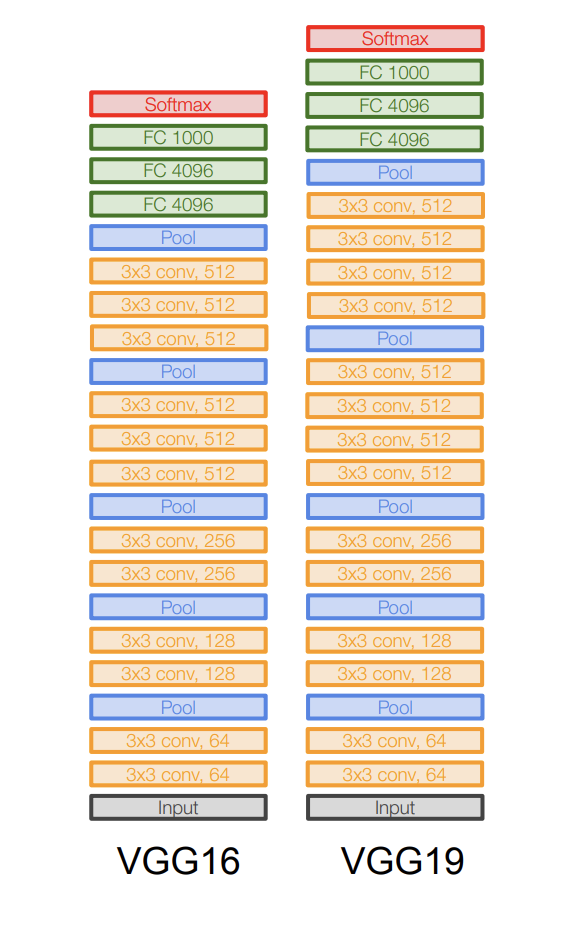

Detalles Técnicos:

Capas convolucionales con filtros de tamaño fijo (3x3).
Usa max-pooling de tamaño 2x2.
Las capas densas tienen 4096 unidades cada una.

Código en keras: tarea!

#### Resnet (Residual Networks)

Paper: https://arxiv.org/abs/1512.03385

Historia y Contexto:

ResNet, que significa Redes Residuales, fue presentada por Kaiming He y sus colegas de Microsoft Research en la competencia ILSVRC de 2015. ResNet fue una innovación revolucionaria en el diseño de arquitecturas profundas de redes neuronales, permitiendo entrenar redes con una profundidad de hasta cientos de capas de manera efectiva.

**Motivaciones para ResNet**

Degradación del Entrenamiento:

Antes de ResNet, a medida que las redes se hacían más profundas, el entrenamiento se volvía ineficiente y la precisión se saturaba o incluso disminuía, un fenómeno no relacionado con el sobreajuste y conocido como degradación del entrenamiento. ResNet fue diseñada para combatir este problema.

Facilitar el Flujo de Gradientes:

Las conexiones residuales, o "skip connections", permiten que el gradiente fluya directamente a través de las capas sin pasar por las transformaciones no lineales, mitigando el problema del gradiente desvanecido o explotante.


Aprendizaje de Funciones Residuales:

Se descubrió que es más fácil optimizar las funciones residuales (la diferencia entre la entrada y la salida de un bloque de capas) que las funciones no residuales (la salida directa de un bloque de capas).

Arquitectura:

ResNet introduce el concepto de bloques residuales, donde la salida de un bloque de capas es sumada a la entrada del bloque, lo que permite que la red aprenda funciones residuales. Si la identidad es la función deseada, la red puede empujar los pesos de las capas convolucionales hacia cero para fácilmente realizar el mapeo identidad.



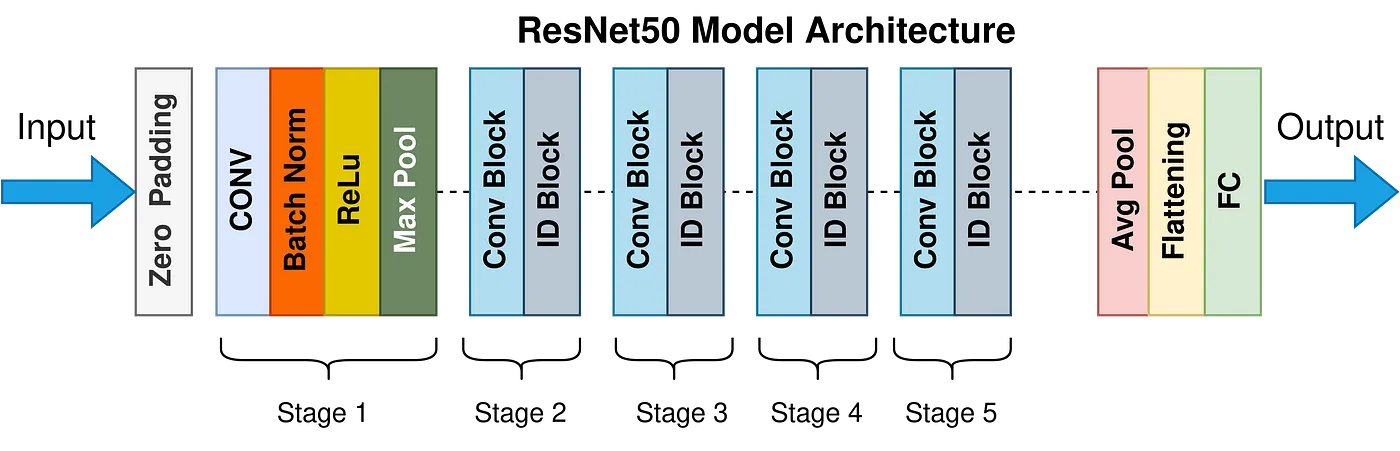

Detalles Técnicos:

Conexiones residuales entre bloques de capas.
Uso de la función de activación ReLU y la inicialización de He para las capas convolucionales.
Uso de normalización por lotes después de cada convolución y antes de la activación.

 ResNet demostró que es posible entrenar redes mucho más profundas de lo que se pensaba anteriormente y que estas redes profundas pueden lograr un rendimiento significativamente mejorado en tareas de visión por computadora.

Skip Connections:

Una de las innovaciones clave introducidas por ResNet es el concepto de skip connections o conexiones de salto. Estas conexiones permiten que la señal de entrada de una capa se "salte" una o más capas y se sume directamente a la salida de una capa más profunda. El propósito principal de las skip connections es combatir el problema del gradiente desvanecido que se produce con el aumento de la profundidad en las redes neuronales.

**Motivación y Beneficios**

Facilitar el Aprendizaje:

Las skip connections facilitan el aprendizaje al proporcionar una ruta alternativa para el flujo de gradientes durante la retropropagación. Esto ayuda a preservar la magnitud del gradiente, permitiendo que la red se entrene eficientemente incluso cuando es muy profunda.

Bloques Residuales:

En ResNet, las skip connections se utilizan dentro de lo que se llama bloques residuales. Un bloque residual típico tiene dos o tres capas convolucionales seguidas por una skip connection que suma la entrada del bloque a su salida.
Entrenamiento de Redes Profundas: Gracias a las skip connections, ResNet ha demostrado ser efectiva al entrenar redes con un número significativo de capas, superando la barrera que existía previamente en la profundidad de las redes neuronales.
Funcionamiento de las Skip Connections:

Identidad:

En el caso más simple, las skip connections realizan una función de identidad, pasando la entrada directamente a la salida. Esto se hace cuando la entrada y la salida del bloque tienen las mismas dimensiones.
Ajuste de Dimensiones: Cuando las dimensiones de la entrada y la salida no coinciden, las skip connections pueden incluir una capa convolucional adicional o una operación de pooling para ajustar las dimensiones antes de sumarlas a la salida.


**Implementación en Keras**:
Las skip connections pueden implementarse manualmente en Keras usando la API funcional.

```
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Add, Activation

# Definición de la entrada
input_tensor = Input(shape=(256, 256, 3))

# Primeras capas convolucionales
x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_tensor)
x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)

# Skip connection que añade la entrada original x
skip_connection = Conv2D(64, (1, 1), padding='same')(input_tensor)
x = Add()([x, skip_connection])
x = Activation('relu')(x)

# Creación del modelo
model = Model(inputs=input_tensor, outputs=x)
model.summary()
```

En este ejemplo, `Add()` fusiona la entrada original con la salida de las capas convolucionales, formando una skip connection. Si las dimensiones son las mismas, se podría pasar la entrada directamente sin necesidad de una convolución adicional.

Consideraciones Adicionales:

Entrenamiento:

Durante el entrenamiento, la red puede aprender a utilizar estas skip connections para mitigar el gradiente desvanecido, lo que permite que cada bloque residual aprenda funciones adicionales a la identidad, lo que mejora la capacidad del modelo.
Normalización: Generalmente, cada conjunto de capas dentro de un bloque residual está seguido por una operación de normalización por lotes antes de la activación.


#### Keras model zoo

Descripción:

El "Model Zoo" en Keras es una colección de modelos de aprendizaje profundo preentrenados que están disponibles para su uso y descarga directa a través de la API de Keras. Estos modelos han sido entrenados en un conjunto de datos estándar como ImageNet y pueden ser utilizados para predicción, extracción de características y fine-tuning (ajuste fino) en conjuntos de datos similares o diferentes.

Utilidad:
El uso del Model Zoo de Keras ofrece varias ventajas:

Ahorro de Tiempo: Evita la necesidad de entrenar una red compleja desde cero.

Mejor Desempeño: Los modelos preentrenados a menudo tienen un desempeño superior debido a que han sido entrenados en grandes conjuntos de datos con una amplia variedad de etiquetas.

Transfer Learning: Puedes aprovechar el conocimiento de estos modelos (transfer learning) para tus propios problemas, incluso si estás trabajando con un conjunto de datos relativamente pequeño. Veremos más de esto luego.

Benchmarking: Facilita la comparación de tu propio modelo contra arquitecturas bien establecidas.
Investigación y Desarrollo: Permite a los investigadores y desarrolladores centrarse más en la experimentación con nuevas ideas en lugar de preocuparse por los detalles de implementación de las arquitecturas estándar.

Ejemplo de uso para la red VGG16:


```
from tensorflow.keras.applications import vgg16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np

# Carga el modelo VGG16 preentrenado en ImageNet
model = vgg16.VGG16(weights='imagenet')

# Cargar una imagen para probar, redimensionarla a 224x224 píxeles (tamaño esperado por VGG16)
img_path = 'path_to_your_image.jpg'
img = image.load_img(img_path, target_size=(224, 224))

# Convertir la imagen a un array de numpy y realizar los preprocesamientos requeridos
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Hacer predicciones sobre la imagen
predictions = model.predict(x)

# Decodificar las predicciones
print('Predicted:', decode_predictions(predictions, top=3)[0])
```